# 00 — California boundary and centre-based spatial grid

Reconstructs the fixed spatial domain used by every model.

- 2024 U.S. Census TIGER/Line state boundary
- bounding box: 32.0–42.5°N, 125.0–114.0°W
- 53 × 55 regular grid
- retain a cell if its centre lies inside California
- expected retained cells: 1,080

In [1]:
from pathlib import Path
import io, os, sys, zipfile
import numpy as np
import pandas as pd
import requests

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "outputs" / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT.resolve())

Repository root: C:\Users\DNY\Downloads


In [2]:
# ==================================================
# California state boundary: PROJ setup + cached download
# ==================================================

import os
import sys
import io
import zipfile
from pathlib import Path

import requests

# --------------------------------------------------
# 1. Configure PROJ before importing geopandas/pyproj
#    This avoids the common Windows/Anaconda PROJ warning.
# --------------------------------------------------
proj_candidates = [
    Path(sys.prefix) / "Library" / "share" / "proj",
    Path(sys.prefix) / "share" / "proj",
]

proj_data_dir = next(
    (p for p in proj_candidates if (p / "proj.db").exists()),
    None
)

if proj_data_dir is not None:
    os.environ["PROJ_DATA"] = str(proj_data_dir)
    os.environ["PROJ_LIB"] = str(proj_data_dir)
else:
    print("Warning: proj.db was not found in the usual Anaconda locations.")
    print("Checked:")
    for p in proj_candidates:
        print(" -", p)

import pyproj

if proj_data_dir is not None:
    pyproj.datadir.set_data_dir(str(proj_data_dir))

import geopandas as gpd

print("PROJ data directory:", pyproj.datadir.get_data_dir())

# --------------------------------------------------
# 2. Download/cache the US Census state shapefile
# --------------------------------------------------
BOUNDARY_DIR = DATA_DIR / "boundary_data"
extract_dir = BOUNDARY_DIR / "tl_2024_us_state"
shapefile_path = extract_dir / "tl_2024_us_state.shp"

STATE_SHAPEFILE_URL = (
    "https://www2.census.gov/geo/tiger/TIGER2024/STATE/"
    "tl_2024_us_state.zip"
)

if not shapefile_path.exists():
    print("State boundary shapefile not found locally.")
    print("Downloading 2024 Census TIGER/Line state boundaries...")

    extract_dir.mkdir(parents=True, exist_ok=True)

    response = requests.get(STATE_SHAPEFILE_URL, timeout=120)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
        zf.extractall(extract_dir)

# Fallback in case the internal filename changes
if not shapefile_path.exists():
    shp_candidates = list(extract_dir.glob("*.shp"))
    if not shp_candidates:
        raise FileNotFoundError(
            f"No shapefile found in {extract_dir.resolve()}"
        )
    shapefile_path = shp_candidates[0]

print("Using state boundary file:", shapefile_path.resolve())

# --------------------------------------------------
# 3. Load US states and retain California
# --------------------------------------------------
us_states = gpd.read_file(
    shapefile_path,
    engine="pyogrio"
)

print("Original CRS:", us_states.crs)

california_boundary = us_states[
    us_states["STUSPS"] == "CA"
].copy()

if california_boundary.empty:
    raise ValueError("California (STUSPS='CA') was not found in the state shapefile.")

california_boundary = california_boundary.to_crs("EPSG:4326")

print("California boundary rows:", len(california_boundary))
print("California CRS:", california_boundary.crs)

display(
    california_boundary[
        ["STATEFP", "STUSPS", "NAME", "geometry"]
    ]
)

d:\anaconda\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


PROJ data directory: d:\anaconda\Library\share\proj
State boundary shapefile not found locally.
Using state boundary file: C:\Users\DNY\Downloads\data\boundary_data\tl_2024_us_state\tl_2024_us_state.shp
Original CRS: EPSG:4269
California boundary rows: 1
California CRS: EPSG:4326


,STATEFP,STUSPS,NAME,geometry
13,06,CA,California,"MULTIPOLYGON (((-119.99986 41.18397, -119.9998..."


## Build the regular grid

In [3]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box

# Study-region boundaries
lat_min, lat_max = 32.0, 42.5
lon_min, lon_max = -125.0, -114.0

# Grid dimensions
n_lat = 53
n_lon = 55

# Grid edges
lat_edges = np.linspace(lat_min, lat_max, n_lat + 1)
lon_edges = np.linspace(lon_min, lon_max, n_lon + 1)

grid_records = []

for lat_idx in range(n_lat):
    for lon_idx in range(n_lon):

        south = lat_edges[lat_idx]
        north = lat_edges[lat_idx + 1]
        west = lon_edges[lon_idx]
        east = lon_edges[lon_idx + 1]

        cell_id = lat_idx * n_lon + lon_idx

        grid_records.append({
            "cell_id": cell_id,
            "lat_idx": lat_idx,
            "lon_idx": lon_idx,
            "south": south,
            "north": north,
            "west": west,
            "east": east,
            "centre_lat": (south + north) / 2,
            "centre_lon": (west + east) / 2,
            "geometry": box(west, south, east, north)
        })

grid_gdf = gpd.GeoDataFrame(
    grid_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print("Total grid cells:", len(grid_gdf))

Total grid cells: 2915


## Apply the centre-based mask

In [4]:
grid_centres_gdf = gpd.GeoDataFrame(
    grid_gdf[
        [
            "cell_id",
            "lat_idx",
            "lon_idx",
            "centre_lon",
            "centre_lat"
        ]
    ].copy(),
    geometry=gpd.points_from_xy(
        grid_gdf["centre_lon"],
        grid_gdf["centre_lat"]
    ),
    crs="EPSG:4326"
)

california_grid_centres = gpd.sjoin(
    grid_centres_gdf,
    california_boundary[["geometry"]],
    how="inner",
    predicate="within"
)

california_cell_ids = set(
    california_grid_centres["cell_id"]
)

grid_gdf["is_california"] = (
    grid_gdf["cell_id"].isin(california_cell_ids)
)

california_grid_gdf = grid_gdf[
    grid_gdf["is_california"]
].copy()

print("Total bounding-box cells:", len(grid_gdf))
print("California mask cells:", len(california_grid_gdf))

print("Total bounding-box cells:", len(grid_gdf))
print("California mask cells:", len(california_grid_gdf))
print(
    "Mask proportion:",
    round(len(california_grid_gdf) / len(grid_gdf), 4)
)

Total bounding-box cells: 2915
California mask cells: 1080
Total bounding-box cells: 2915
California mask cells: 1080
Mask proportion: 0.3705


In [5]:
assert len(grid_gdf) == 2915
assert len(california_grid_gdf) == 1080
assert california_grid_gdf["cell_id"].is_unique
assert california_grid_gdf["is_california"].all()

mask_csv = DATA_DIR / "california_grid_centre_mask.csv"
mask_geojson = DATA_DIR / "california_grid_centre_mask.geojson"

california_grid_gdf.drop(columns="geometry").to_csv(mask_csv, index=False)
california_grid_gdf.to_file(mask_geojson, driver="GeoJSON")

print("Saved:", mask_csv)
print("Saved:", mask_geojson)

Saved: c:\Users\DNY\Downloads\data\california_grid_centre_mask.csv
Saved: c:\Users\DNY\Downloads\data\california_grid_centre_mask.geojson


## Spatial-domain figures

In [16]:
# ============================================================
# Figures used to document the spatial study design
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
import folium


# ============================================================
# Figure 1: catalogue-retrieval bounding box
# ============================================================

# Same geographic bounds used for the ComCat catalogue query
lat_min, lat_max = 32.0, 42.5
lon_min, lon_max = -125.0, -114.0

bbox_map = folium.Map(
    location=[37.25, -119.5],
    zoom_start=5,
    tiles="OpenStreetMap"
)

bounds = [
    [lat_min, lon_min],
    [lat_max, lon_max]
]

folium.Rectangle(
    bounds=bounds,
    color="red",
    weight=3,
    fill=True,
    fill_color="red",
    fill_opacity=0.10,
    dash_array="5, 5"
).add_to(bbox_map)

bbox_map.fit_bounds(bounds)

bbox_html = FIGURE_DIR / "california_real_map_bbox.html"
bbox_map.save(str(bbox_html))

print("Saved bounding-box map:")
print(bbox_html)

# Display interactive map in notebook
bbox_map

Saved bounding-box map:
c:\Users\DNY\Downloads\outputs\figures\california_real_map_bbox.html


C:\Users\DNY\AppData\Local\Temp\ipykernel_39632\4088024959.py:13: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  display_mask_grid.geometry.notna()
C:\Users\DNY\AppData\Local\Temp\ipykernel_39632\4088024959.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  & (display_mask_grid.geometry.area > 0)


Display grid cells: 1218
Centre-based modelling cells: 1080


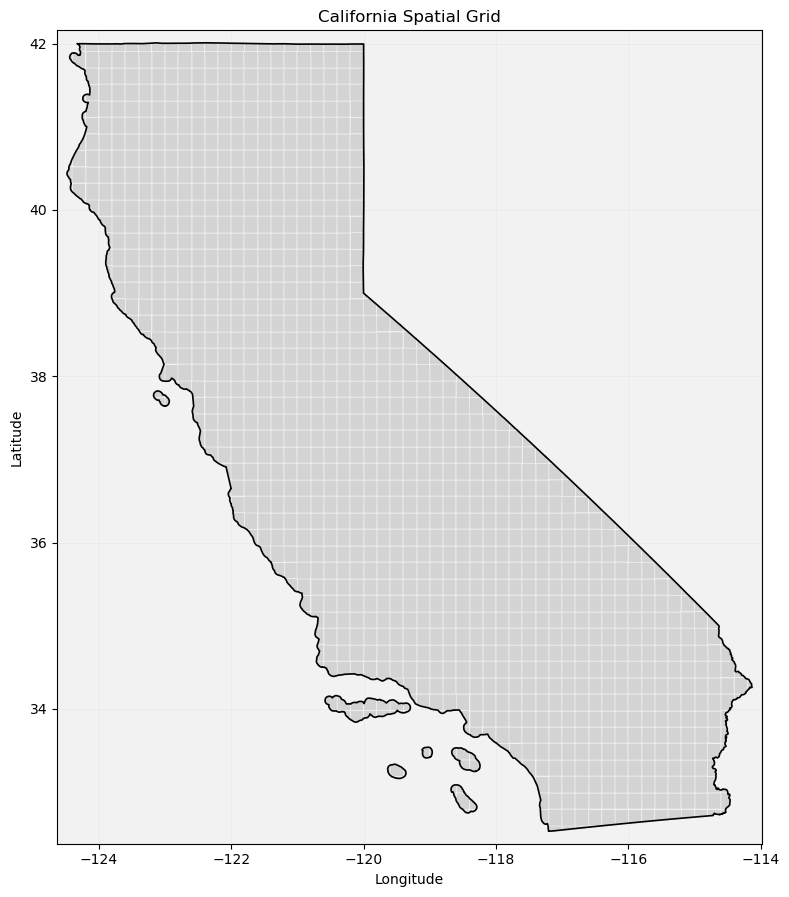

In [15]:
try:
    california_union = california_boundary.geometry.union_all()
except AttributeError:
    california_union = california_boundary.geometry.unary_union

display_mask_grid = grid_gdf.copy()

display_mask_grid["geometry"] = (
    display_mask_grid.geometry.intersection(california_union)
)

display_mask_grid = display_mask_grid[
    display_mask_grid.geometry.notna()
    & (~display_mask_grid.geometry.is_empty)
    & (display_mask_grid.geometry.area > 0)
].copy()

print("Display grid cells:", len(display_mask_grid))
print("Centre-based modelling cells:", len(california_grid_gdf))

fig, ax = plt.subplots(figsize=(8, 10))

ax.set_facecolor("#f2f2f2")

display_mask_grid.plot(
    ax=ax,
    facecolor="lightgrey",
    edgecolor="white",
    linewidth=0.30
)

california_boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.2
)

minx, miny, maxx, maxy = california_boundary.total_bounds

ax.set_xlim(minx - 0.15, maxx + 0.15)
ax.set_ylim(miny - 0.15, maxy + 0.15)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("California Spatial Grid")

ax.grid(
    alpha=0.18,
    linewidth=0.4
)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "california_spatial_grid_display.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()